<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Document_Processing_with_PaddleOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dcument Processing with PaddleOCR

In [ ]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 6.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB

In [ ]:
# You need to install paddlepaddle superatedly appart from paddlleocr othe
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


In [ ]:
# Make import superately make sure the version matches
from paddleocr import PaddleOCR

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [ ]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import AgentExecutor
import csv

In [ ]:
import os
from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

## 1. PaddleOCR Basic

In [ ]:
# Initialize english OCR model
ocr = PaddleOCR(lang='en')

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional t

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

inference.json: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/7.77M [00:00<?, ?B/s]

inference.yml: 0.00B [00:00, ?B/s]

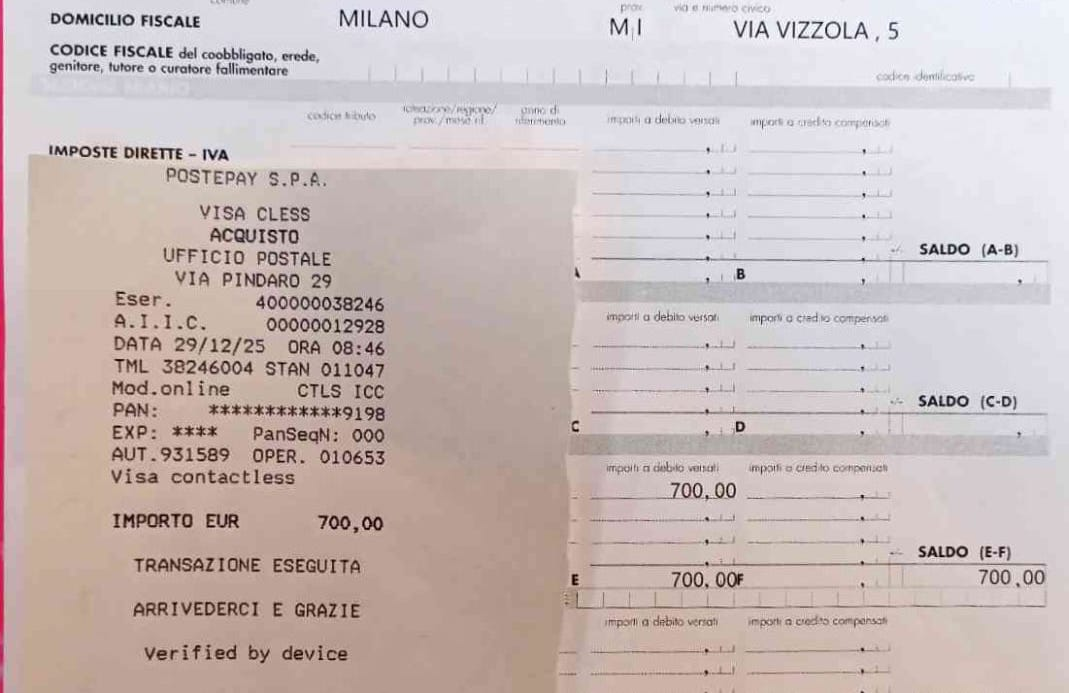

In [ ]:
from IPython.display import display

image_path = 'noisy_img.jpeg'
img = Image.open(image_path)
display(img)

In [ ]:
import paddleocr
import paddle

In [ ]:
print("paddleocr version: ", paddleocr.__version__)
print("paddle version: ", paddle.__version__)


paddleocr version:  3.3.3
paddle version:  3.2.0


In [ ]:
# Run OCR
result = ocr.predict(image_path)

In [ ]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes = page['rec_polys'] # bounding box coordinates

for text, score, box in zip(texts, scores, boxes): # zip -> ties together items with the same position
  # box is a numpy array
  coords = box.astype(int).tolist() # convert to normal list of ints
  print(f"{text:25} | {score:.3f} | {coords}")

DOMICILIO FISCALE         | 0.999 | [[21, 0], [179, 0], [179, 20], [20, 16]]
MILANO                    | 0.937 | [[331, 1], [412, 1], [412, 14], [331, 14]]
MT                        | 0.777 | [[597, 0], [642, 0], [642, 24], [597, 24]]
VIA VIZZOLA, 5            | 0.968 | [[728, 0], [905, 0], [905, 20], [728, 20]]
CODICE FISCALE del coobbligato, erede, | 0.987 | [[22, 28], [302, 34], [301, 53], [21, 48]]
genitore, tutore o curatore fallimentare | 0.982 | [[21, 47], [270, 48], [270, 68], [21, 67]]
codice demilicative       | 0.744 | [[876, 43], [991, 39], [991, 64], [877, 67]]
codice sibulo             | 0.788 | [[284, 94], [362, 94], [362, 115], [284, 115]]
(ChcUc/0/                 | 0.583 | [[383, 87], [485, 87], [485, 106], [383, 106]]
gnnod                     | 0.718 | [[504, 88], [554, 85], [555, 103], [505, 106]]
pRO/md.                   | 0.502 | [[394, 100], [477, 98], [478, 116], [394, 118]]
iommen                    | 0.482 | [[502, 101], [561, 101], [561, 115], [502, 115]]
i

In [ ]:
# Preproccess the image
img = page['doc_preprocessor_res']['output_img']

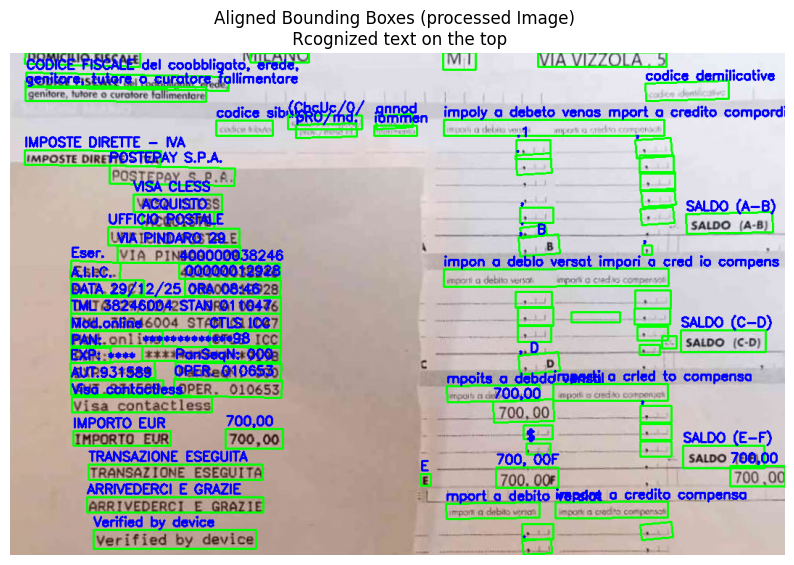

In [ ]:
# display preprocessed image with all items overlayed
img_plot = img.copy()
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  cv2.putText(img_plot, text, (x, y-5),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (processed Image) \n Rcognized text on the top")
plt.show()

## 1.1 Create the PaddleOCR Tool
Turn PaddleOCR to a tool so that can be used with an agent

In [ ]:
from langchain.tools import tool
import base64
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any

@tool
def paddle_ocr_read_document(image_path: str) -> List[Dict[str, Any]]:
  """
  Reads an image from the given path and returns extracted text
  with bounding boxes.

  Returns a list of dictionaries, each containing:
  - 'text': the recognized text string
  - 'bbox': bounding box coordinates [x_min, y_min, x_max, y_max]
  - 'confidence': recognition confidence score (if available)
  """
  try:
    result = ocr.predict(image_path) # from paddleOCR
    page = result[0]

    texts = page['rec_texts']
    boxes = page['dt_polys']
    scores = page.get('rec_scores', [None] * len(texts))

    extracted_items = []
    for text, box, score in zip(texts, boxes, scores):
      x_coords = [point[0] for point in box]
      y_coords = [point[1] for point in box]
      bbox = [min(x_coords), min(y_coords), max(x_coords),
              max(y_coords)]

      item = {
          'text': text,
          'bbox': bbox
      }

      if score is not None:
        item['confidance'] = score
      extracted_items.append(item)
    return extracted_items
  except Exception as e:
    return [{'error': f'Error reading image {e}'}]

## 1.2 Create & Run the Agent


In [ ]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document]

# 2. Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [ ]:
from langchain.agents import create_tool_calling_agent
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant designed to extract information "+
        "from documents. "
          "You have access to this tool: "
          "Paddle OCR tool to extract raw texts, bounding boxes for "+
          "each text and confidence score from images "
    ),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name='agent_scratchpad'),
])

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
# Run the agent and extract information
task = """
Process the document at 'noisy_img.jpeg' and evaluate that
the total amount is correct.
"""

response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...

Invoking: `paddle_ocr_read_document` with `{'image_path': 'noisy_img.jpeg'}`


[{'text': 'DOMICILIO FISCALE', 'bbox': [np.int16(20), np.int16(0), np.int16(179), np.int16(20)], 'confidance': 0.9993115663528442}, {'text': 'MILANO', 'bbox': [np.int16(331), np.int16(1), np.int16(412), np.int16(14)], 'confidance': 0.9368214011192322}, {'text': 'MT', 'bbox': [np.int16(597), np.int16(0), np.int16(642), np.int16(24)], 'confidance': 0.7772237062454224}, {'text': 'VIA VIZZOLA, 5', 'bbox': [np.int16(728), np.int16(0), np.int16(905), np.int16(20)], 'confidance': 0.9681915044784546}, {'text': 'CODICE FISCALE del coobbligato, erede,', 'bbox': [np.int16(21), np.int16(28), np.int16(302), np.int16(53)], 'confidance': 0.9871707558631897}, {'text': 'genitore, tutore o curatore fallimentare', 'bbox': [np.int16(21), np.int16(47), np.int16(270), np.int16(68)], 'confidance': 0.9819205403327942}, {'text': 'codice demilicative', 'bbox': [np.int16(876), np.int16(39), np.

## 1.3. Run PaddleOCR on the Table and Handwriting examples

In [ ]:
def run_ocr(image_path, ocr_model=ocr, show_text=True):
  display(Image.open(image_path))
  result = ocr.predict(image_path) # result from paddleOCR

  page = result[0]
  texts = page['rec_texts']
  scores = page['rec_scores']
  boxes = page['rec_polys']

  for text, score, box in zip(texts, scores, boxes):
    coords = box.astype(int).tolist()
    print(f'{text:25} | {score:.3f} | {coords}')

  # post proccessed image
  img = page['doc_preprocessor_res']['output_img']
  img_plot = img.copy()

  image_path = Path(image_path)
  output_path = image_path.with_stem(image_path.stem + '_output')
  cv2.imwrite(str(output_path), img, [cv2.IMWRITE_JPEG_QUALITY, 70])

  # Make some annotation on top using bounding box cordinate
  for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    if show_text:
      cv2.putText(img_plot, text,
                  (x, y-5), cv2.FONT_HERSHEY_SIMPLEX,
                  1.0, (255, 0, 0), 2)

  plt.figure(figsize=(10, 12))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_RGB2RGBA))
  plt.axis('off')

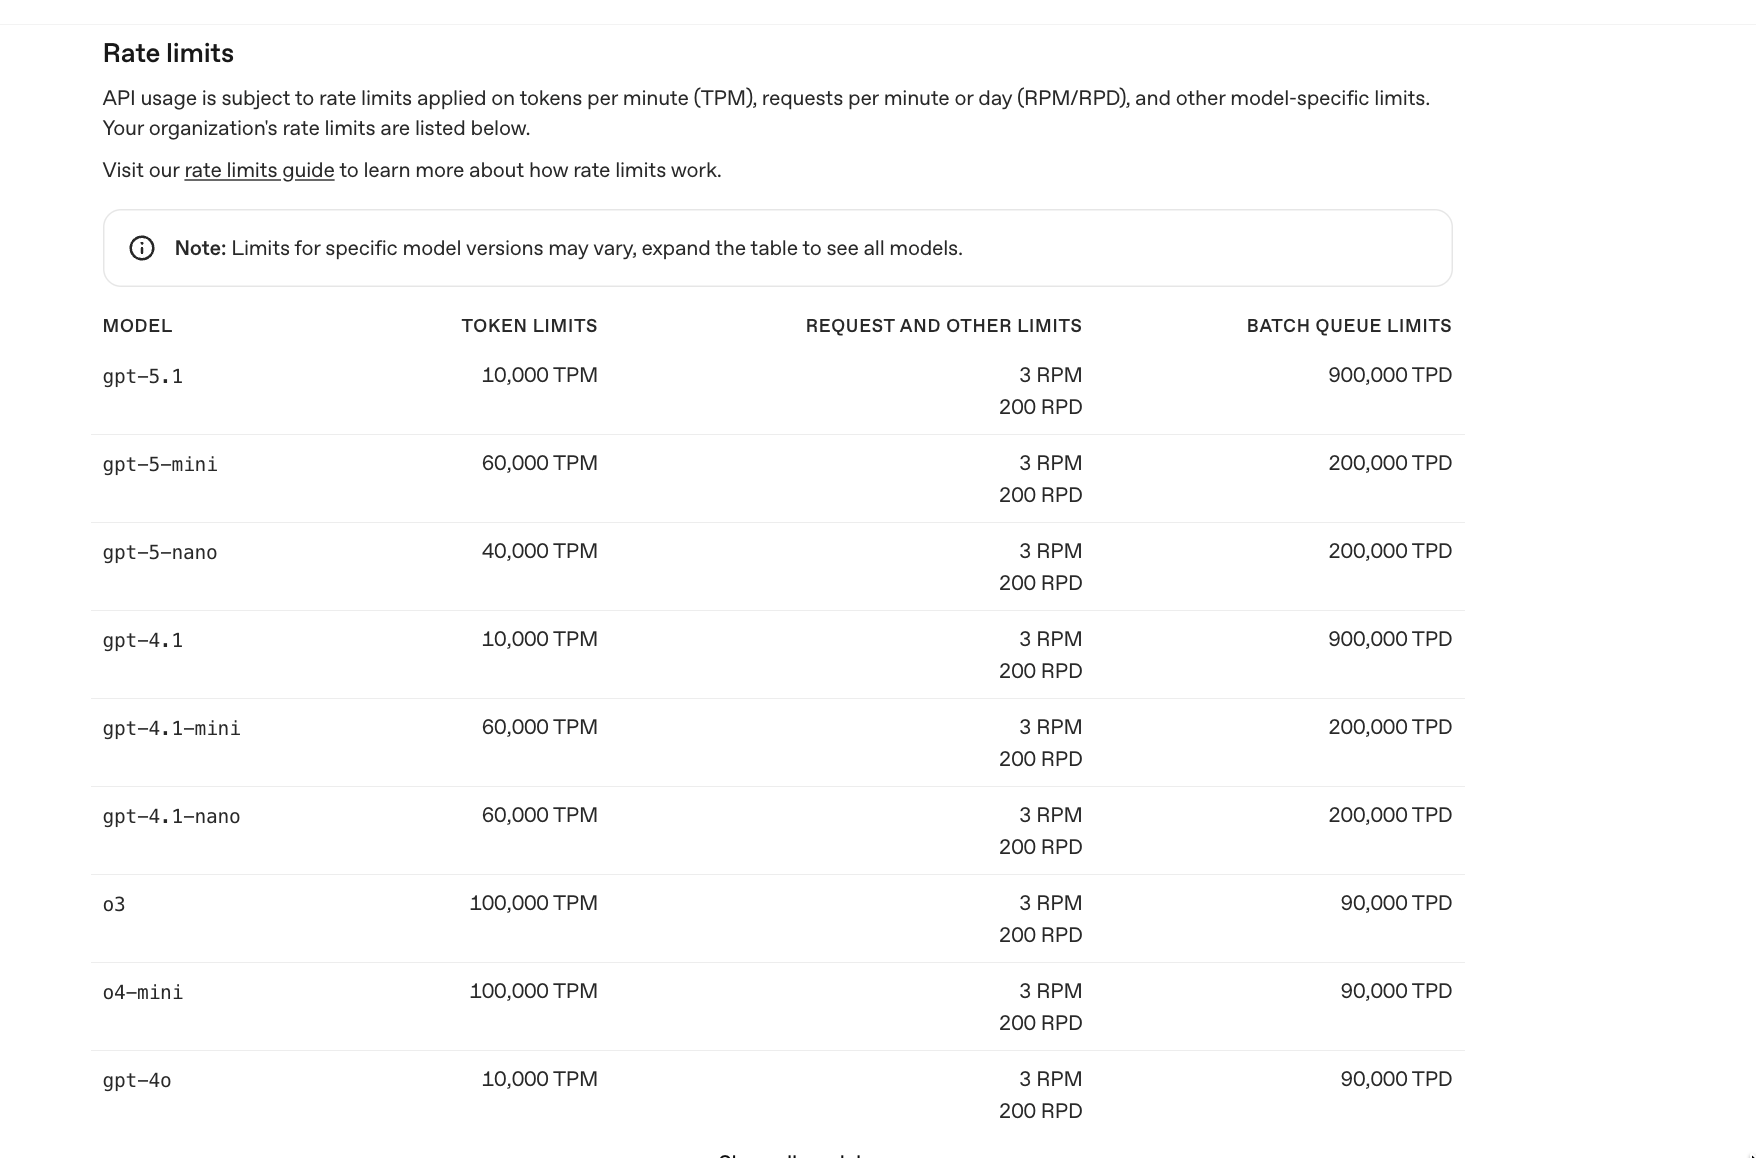

Rate limits               | 0.998 | [[22, 8], [181, 10], [180, 40], [22, 38]]
Your organization's rate limits are listed below. | 0.995 | [[17, 90], [510, 98], [510, 122], [17, 114]]
Visit our rate limits guide to learn more about how rate limits work. | 0.986 | [[13, 135], [722, 142], [722, 169], [13, 162]]
0                         | 0.223 | [[45, 219], [85, 219], [85, 247], [45, 247]]
Note: Limits for specific model versions may vary, expand the table to see all models. | 0.976 | [[80, 221], [988, 229], [988, 255], [80, 247]]
MODEL                     | 1.000 | [[9, 308], [100, 308], [100, 329], [9, 329]]
TOKENLIMITS               | 0.987 | [[429, 313], [581, 313], [581, 327], [429, 327]]
BEOUESTAND OTHER LIMITS   | 0.960 | [[812, 316], [1113, 316], [1113, 330], [812, 330]]
OUEUE LIMITS              | 0.993 | [[1377, 312], [1536, 310], [1537, 327], [1377, 329]]
gpt-5.1                   | 1.000 | [[9, 363], [113, 357], [114, 383], [10, 388]]
3 RPM                     | 0.922 | [[104

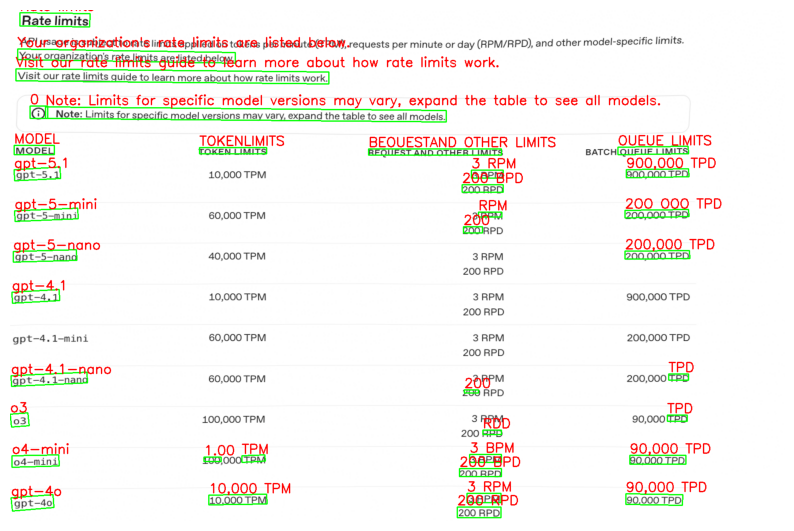

In [ ]:
# image source: https://www.nature.com/articles/s41597-024-03605-5/figures/4
run_ocr('open-ai-rate-limit.png')

In [ ]:
task = """
This is the OpenAI rate limit table. I am only using it for extracting text from images and chat with the extracted text
information from the image. My daily usage is between 5 to 10 hit now please process the document at 'open-ai-rate-limit.png'
and tell me which model is the best I can use to avoid an extra payment.
"""

response = agent_executor.invoke({'input': task})

# Display results side by side
print('\n' + '_'*35 + 'LLM RESULT ' + '_'*33)
print("="*80)
print(response['output'])
print('='*80)



> Entering new AgentExecutor chain...

Invoking: `paddle_ocr_read_document` with `{'image_path': 'open-ai-rate-limit.png'}`


[{'text': 'Rate limits', 'bbox': [np.int16(22), np.int16(8), np.int16(181), np.int16(40)], 'confidance': 0.9979733824729919}, {'text': "Your organization's rate limits are listed below.", 'bbox': [np.int16(17), np.int16(90), np.int16(510), np.int16(122)], 'confidance': 0.995158314704895}, {'text': 'Visit our rate limits guide to learn more about how rate limits work.', 'bbox': [np.int16(13), np.int16(135), np.int16(722), np.int16(169)], 'confidance': 0.9863271117210388}, {'text': '0', 'bbox': [np.int16(45), np.int16(219), np.int16(85), np.int16(247)], 'confidance': 0.22276324033737183}, {'text': 'Note: Limits for specific model versions may vary, expand the table to see all models.', 'bbox': [np.int16(80), np.int16(221), np.int16(988), np.int16(255)], 'confidance': 0.975671112537384}, {'text': 'MODEL', 'bbox': [np.int16(9), np.int16(308), np.int16(100), np.int